# Data cleaning & manipulation

## Libraries

In [199]:
import pandas as pd
from sklearn.model_selection import train_test_split
from category_encoders import TargetEncoder
import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))
from src.data_cleaning_and_manipulations import impute_by_agency_line_hour
import matplotlib.pyplot as plt
import seaborn as sns



## Imports

In [200]:
train_df = pd.read_csv(r'../data/model_datasets/train_df.csv', encoding='utf-8-sig')
val_df = pd.read_csv(r'../data/model_datasets/val_df.csv', encoding='utf-8-sig')
test_df = pd.read_csv(r'../data/model_datasets/test_df.csv', encoding='utf-8-sig')

print(f"Train:      {len(train_df):,} rows")
print(f"Validation: {len(val_df):,} rows")
print(f"Test:       {len(test_df):,} rows")
print(f"Total:      {len(train_df) + len(val_df) + len(test_df):,} rows")

Train:      54,546 rows
Validation: 9,091 rows
Test:       27,274 rows
Total:      90,911 rows


In [201]:
train_df.columns

Index(['date', 'day', 'full_hour', 'line_num', 'line_name', 'route_id',
       'route_mkt', 'direction', 'alternative', 'agency_name', 'route_type',
       'origin_city', 'origin_station', 'destination_city',
       'destination_station', 'number_of_stops', 'route_length_km',
       'departure_time_planned', 'arrival_time_planned',
       'duration_min_planned', 'duration_min_actual',
       'duration_difference_min', 'speed_kmh_planned', 'speed_kmh_actual',
       'rainfall_mm', 'length_in_buffer_m', 'route_length', 'curvity',
       'circular_route', 'Total_Passengers', 'Avg_Passengers_Per_Bus'],
      dtype='object')

## 1. Add Features

In [202]:
def add_features(df):
    """Add new features"""
    
    peak_hours = [7, 8, 9, 14, 15, 16, 17]
    
    # Peak hour flag
    df['is_peak_hour'] = df['full_hour'].isin(peak_hours).astype(int)
    
    # Urban flag
    df['urban'] = df['route_length'] <= 25000
    
    # Perc within pt route
    df['perc_within_pt_route'] = df['length_in_buffer_m'] / df['route_length']
    
    # Peak weighted perc
    df['perc_within_pt_route_peak'] = df.apply(
        lambda row: row['perc_within_pt_route'] if row['full_hour'] in peak_hours else 0, axis=1
    )
    
    # Interaction features
    df['passengers_x_peak'] = df['Total_Passengers'] * df['is_peak_hour']
    df['stops_x_passengers'] = df['number_of_stops'] * df['Total_Passengers']
    
    # arrival_hour and departure_hour features
    df['departure_hour'] = pd.to_datetime(df['departure_time_planned'], format='mixed').dt.hour
    df['arrival_hour'] = pd.to_datetime(df['arrival_time_planned'], format='mixed').dt.hour


    
    return df


In [203]:
train_df = add_features(train_df)
val_df = add_features(val_df)
test_df = add_features(test_df)


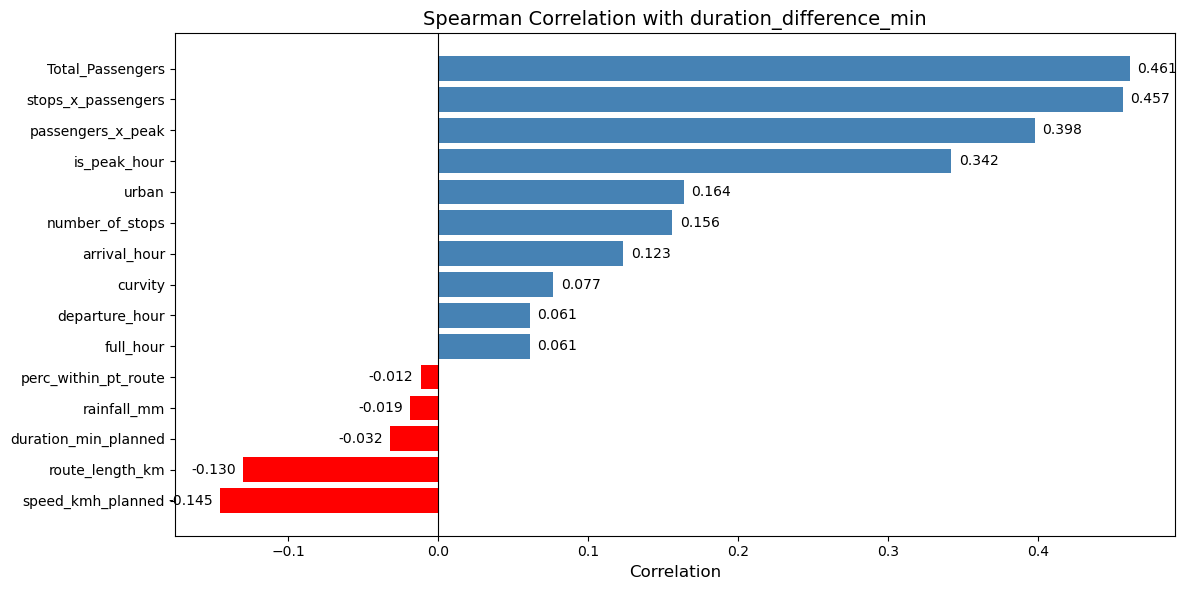

In [204]:
numerical_cols = ['full_hour', 'route_length_km', 'number_of_stops', 'rainfall_mm', 'departure_hour', 'arrival_hour',
                  'Total_Passengers', 'curvity',
                  'duration_min_planned', 'speed_kmh_planned', 'perc_within_pt_route', 'is_peak_hour', 'passengers_x_peak', 'stops_x_passengers' ,'urban' ]

# חשב קורלציה עם המטרה
corr_with_target = train_df[numerical_cols].corrwith(train_df['duration_difference_min'], method='spearman').sort_values()

# צבע לפי חיובי/שלילי
colors = ['red' if x < 0 else 'steelblue' for x in corr_with_target]

plt.figure(figsize=(12, 6))
bars = plt.barh(corr_with_target.index, corr_with_target.values, color=colors)

# data labels
for bar, val in zip(bars, corr_with_target.values):
    plt.text(val + 0.005 if val >= 0 else val - 0.005,
             bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=10)

plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Spearman Correlation with duration_difference_min', fontsize=14)
plt.xlabel('Correlation', fontsize=12)
plt.tight_layout()
plt.show()

## 2. Manage Data types

In [205]:
def fix_data_types(df):
    """Fix all column types and rename columns"""
    
    # Date
    df['date'] = pd.to_datetime(df['date'])
    
    # Departure and arrival times
    df['departure_time_planned'] = pd.to_datetime(
        df['date'].dt.strftime('%Y-%m-%d') + ' ' + 
        pd.to_datetime(df['departure_time_planned'], format='mixed').dt.strftime('%H:%M:%S'),
        format='%Y-%m-%d %H:%M:%S'
    )
    df['arrival_time_planned'] = pd.to_datetime(
        df['date'].dt.strftime('%Y-%m-%d') + ' ' + 
        pd.to_datetime(df['arrival_time_planned'], format='mixed').dt.strftime('%H:%M:%S'),
        format='%Y-%m-%d %H:%M:%S'
    )
    
    # Hour
    if 'hour_rounded' in df.columns:
        df = df.rename(columns={'hour_rounded': 'full_hour'})
    
    # Line_num
    df['line_num'] = pd.to_numeric(df['line_num'], errors='coerce').astype('Int64')
    
    # Day - categorical with order
    day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
    df['day'] = pd.Categorical(df['day'], categories=day_order, ordered=True)
    
    # String columns
    str_cols = ['line_name', 'alternative', 'agency_name', 'origin_city', 
                'origin_station', 'destination_city', 'destination_station', 'route_type']
    df[str_cols] = df[str_cols].astype(str)
    df['route_type'] = df['route_type'].str.strip()

    # Bool columns
    df['urban'] = df['urban'].astype(int)
    
    return df

In [206]:
# Run
train_df = fix_data_types(train_df)
val_df   = fix_data_types(val_df)
test_df  = fix_data_types(test_df)

In [207]:
# day - categorical with order
day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
train_df['day'] = pd.Categorical(train_df['day'], categories=day_order, ordered=True)
print(train_df['day'].dtype)
str_cols = ['line_name', 'alternative', 'agency_name', 'origin_city', 
            'origin_station', 'destination_city', 'destination_station', 'route_type']
train_df[str_cols] = train_df[str_cols].astype(str)
train_df['route_type'] = train_df['route_type'].str.strip()

category


## 3. Missing values handling

In [208]:
missing_summary = pd.DataFrame({
    'missing_count': train_df.isnull().sum(),
    'missing_percent': train_df.isnull().mean() * 100
})

missing_summary = missing_summary.sort_values(by='missing_percent', ascending=False)

missing_summary

,missing_count,missing_percent
Avg_Passengers_Per_Bus,691,1.266821
Total_Passengers,691,1.266821
stops_x_passengers,691,1.266821
passengers_x_peak,691,1.266821
line_num,110,0.201665
length_in_buffer_m,109,0.199831
perc_within_pt_route,109,0.199831
curvity,109,0.199831
circular_route,109,0.199831
speed_kmh_actual,71,0.130165


In [209]:
def handle_missing_values(df, ref_df=None):
    """
    Handle missing values.
    ref_df = Train df (for calculating medians/means)
    If ref_df=None, uses df itself (for train only)
    """
    if ref_df is None:
        ref_df = df
    
    # המר day ל-string לצורך groupby
    df['day'] = df['day'].astype(str)
    
    # Step 1-4: Progressive groupby for Total_Passengers
    for col in ['Total_Passengers']:
        df[col] = df.groupby(['route_id', 'direction', 'day', 'full_hour'])[col].transform(
            lambda x: x.fillna(x.median())
        )
        print(f"{col} missing after step 1: {df[col].isna().sum()}")
        
        df[col] = df.groupby(['route_id', 'direction', 'day'])[col].transform(
            lambda x: x.fillna(x.median())
        )
        print(f"{col} missing after step 2: {df[col].isna().sum()}")
        
        df[col] = df.groupby(['route_id'])[col].transform(
            lambda x: x.fillna(x.median())
        )
        print(f"{col} missing after step 3: {df[col].isna().sum()}")
        
        df[col] = df[col].fillna(ref_df[col].median())
        print(f"{col} missing after step 4: {df[col].isna().sum()}")
    
    # מלא פיצ'רים שתלויים ב-Total_Passengers
    df['passengers_x_peak'] = df['Total_Passengers'] * df['is_peak_hour']
    df['stops_x_passengers'] = df['number_of_stops'] * df['Total_Passengers']
    
    # Avg_Passengers_Per_Bus
    df['Avg_Passengers_Per_Bus'] = df.groupby('route_id')['Avg_Passengers_Per_Bus'].transform(
        lambda x: x.fillna(x.median())
    )
    df['Avg_Passengers_Per_Bus'] = df['Avg_Passengers_Per_Bus'].fillna(ref_df['Avg_Passengers_Per_Bus'].median())
    
    # perc_within_pt_route
    df['perc_within_pt_route'] = df['perc_within_pt_route'].fillna(ref_df['perc_within_pt_route'].mean())
    
    # חשב מחדש perc_within_pt_route_peak
    peak_hours = [7, 8, 9, 14, 15, 16, 17]
    df['perc_within_pt_route_peak'] = df.apply(
        lambda row: row['perc_within_pt_route'] if row['full_hour'] in peak_hours else 0, axis=1
    )
    
    # circular_route
    df['circular_route'] = df['circular_route'].fillna(0)
    
    # speed, duration
    for col in ['speed_kmh_actual', 'duration_min_actual', 'duration_difference_min']:
        df[col] = df.groupby(['route_id', 'direction'])[col].transform(
            lambda x: x.fillna(x.median())
        )
        df[col] = df[col].fillna(ref_df[col].median())
    
    # Geometric columns
    geo_cols = ['curvity', 'route_length', 'length_in_buffer_m']
    for col in geo_cols:
        if col in df.columns:
            df[col] = df[col].fillna(ref_df[col].mean())
    
    # Missing summary
    missing_summary = pd.DataFrame({
        'missing_count': df.isnull().sum(),
        'missing_percent': df.isnull().mean() * 100
    }).sort_values(by='missing_percent', ascending=False)
    
    print("\nMissing Summary:")
    print(missing_summary[missing_summary['missing_count'] > 0])
    
    return df


In [210]:
# Run
train_df = handle_missing_values(train_df, ref_df=None)
val_df   = handle_missing_values(val_df, ref_df=train_df)
test_df  = handle_missing_values(test_df, ref_df=train_df)

Total_Passengers missing after step 1: 691
Total_Passengers missing after step 2: 57
Total_Passengers missing after step 3: 15
Total_Passengers missing after step 4: 0

Missing Summary:
          missing_count  missing_percent
line_num            110         0.201665
Total_Passengers missing after step 1: 110
Total_Passengers missing after step 2: 39
Total_Passengers missing after step 3: 9
Total_Passengers missing after step 4: 0

Missing Summary:
          missing_count  missing_percent
line_num             21         0.230998
Total_Passengers missing after step 1: 316
Total_Passengers missing after step 2: 42
Total_Passengers missing after step 3: 6
Total_Passengers missing after step 4: 0

Missing Summary:
          missing_count  missing_percent
line_num             51         0.186991


In [211]:
missing_summary = pd.DataFrame({
    'missing_count': train_df.isnull().sum(),
    'missing_percent': train_df.isnull().mean() * 100
})

missing_summary = missing_summary.sort_values(by='missing_percent', ascending=False)

missing_summary

,missing_count,missing_percent
line_num,110,0.201665
date,0,0.000000
Total_Passengers,0,0.000000
speed_kmh_planned,0,0.000000
speed_kmh_actual,0,0.000000
rainfall_mm,0,0.000000
length_in_buffer_m,0,0.000000
route_length,0,0.000000
curvity,0,0.000000
circular_route,0,0.000000


## 4. Outliers handling

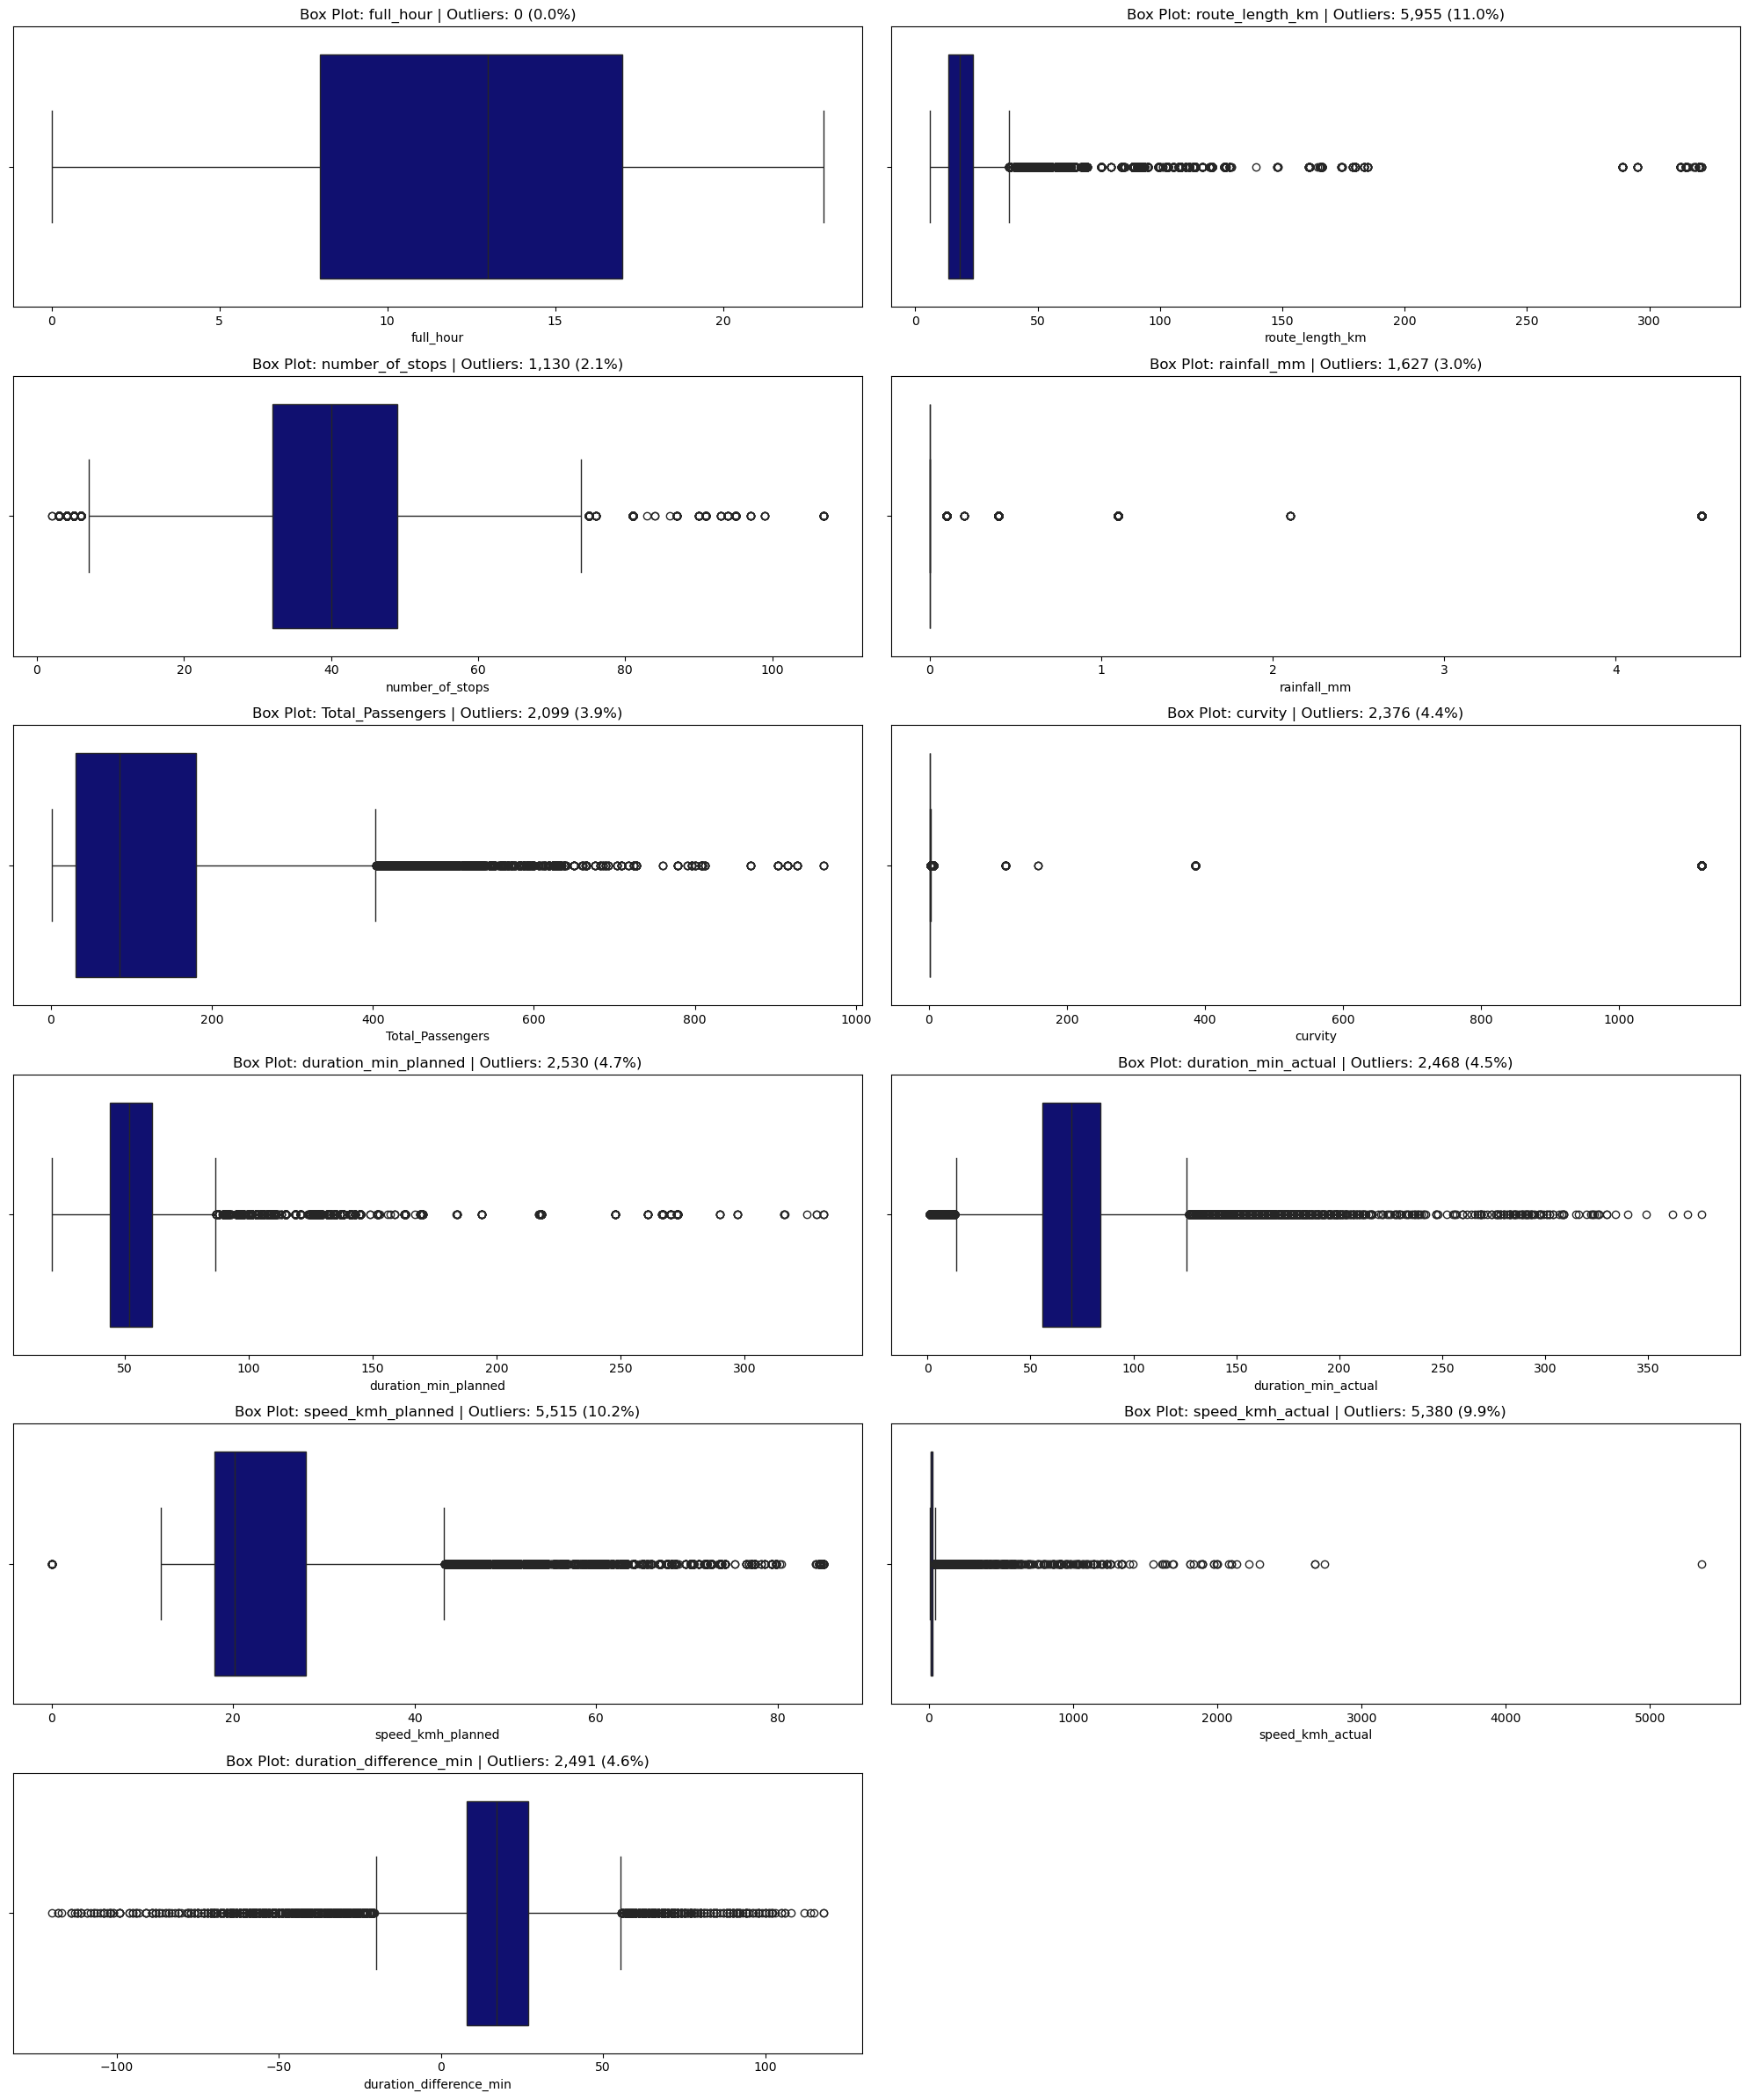

In [212]:
plt.figure(figsize=(20, 24))
cols = ['full_hour', 'route_length_km', 'number_of_stops', 'rainfall_mm', 'Total_Passengers', 
        'curvity', 'duration_min_planned', 'duration_min_actual', 'speed_kmh_planned', 'speed_kmh_actual', 'duration_difference_min']

for i, col in enumerate(cols):
    ax = plt.subplot(6, 2, i + 1)
    sns.boxplot(data=df, x=col, ax=ax, color='navy')
    plt.subplots_adjust(hspace=0.5, wspace=0.3)
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = len(df[(df[col] < lower) | (df[col] > upper)])
    pct_outliers = n_outliers / len(df) * 100
    
    plt.title(f'Box Plot: {col} | Outliers: {n_outliers:,} ({pct_outliers:.1f}%)', fontsize=12)
    plt.xlabel(col, fontsize=10)

plt.tight_layout()
plt.show()

In [213]:
def handle_outliers(df):
    """
    Handle outliers:
    - Fix speed_kmh_planned > 100
    - Fix trips ending after midnight
    - Remove rows where duration_difference_min > 120 or < -120
    """
    
    # Fix speed > 100
    mask_high = df['speed_kmh_planned'] > 100
    print(f"Rows with speed > 100: {mask_high.sum()}")
    df.loc[mask_high, 'speed_kmh_planned'] = df.loc[mask_high, 'speed_kmh_planned'] / 1000
    
    # Fix trips ending after midnight
    df['departure_time_planned'] = pd.to_datetime(df['departure_time_planned'].astype(str), format='mixed')
    df['arrival_time_planned'] = pd.to_datetime(df['arrival_time_planned'].astype(str), format='mixed')
    
    mask_midnight = df['arrival_time_planned'] < df['departure_time_planned']
    print(f"Trips ending after midnight: {mask_midnight.sum()}")
    
    df.loc[mask_midnight, 'duration_min_planned'] = (
        (df.loc[mask_midnight, 'arrival_time_planned'] + pd.Timedelta(days=1)) - 
        df.loc[mask_midnight, 'departure_time_planned']
    ).dt.total_seconds() / 60
    
    df.loc[mask_midnight, 'speed_kmh_planned'] = (
        (df.loc[mask_midnight, 'route_length'] / 1000) / 
        (df.loc[mask_midnight, 'duration_min_planned'] / 60)
    )
    
    # Remove duration_difference_min outliers
    before = len(df)
    df = df[(df['duration_difference_min'] >= -120) & 
            (df['duration_difference_min'] <= 120)]
    after = len(df)
    print(f"Rows removed: {before - after:,} ({(before-after)/before*100:.2f}%)")
    print(f"Rows remaining: {after:,}")
    
    return df



In [214]:
# Run
train_df = handle_outliers(train_df)
val_df   = handle_outliers(val_df)
test_df  = handle_outliers(test_df)

Rows with speed > 100: 0
Trips ending after midnight: 893
Rows removed: 231 (0.42%)
Rows remaining: 54,315
Rows with speed > 100: 0
Trips ending after midnight: 153
Rows removed: 27 (0.30%)
Rows remaining: 9,064
Rows with speed > 100: 0
Trips ending after midnight: 484
Rows removed: 108 (0.40%)
Rows remaining: 27,166


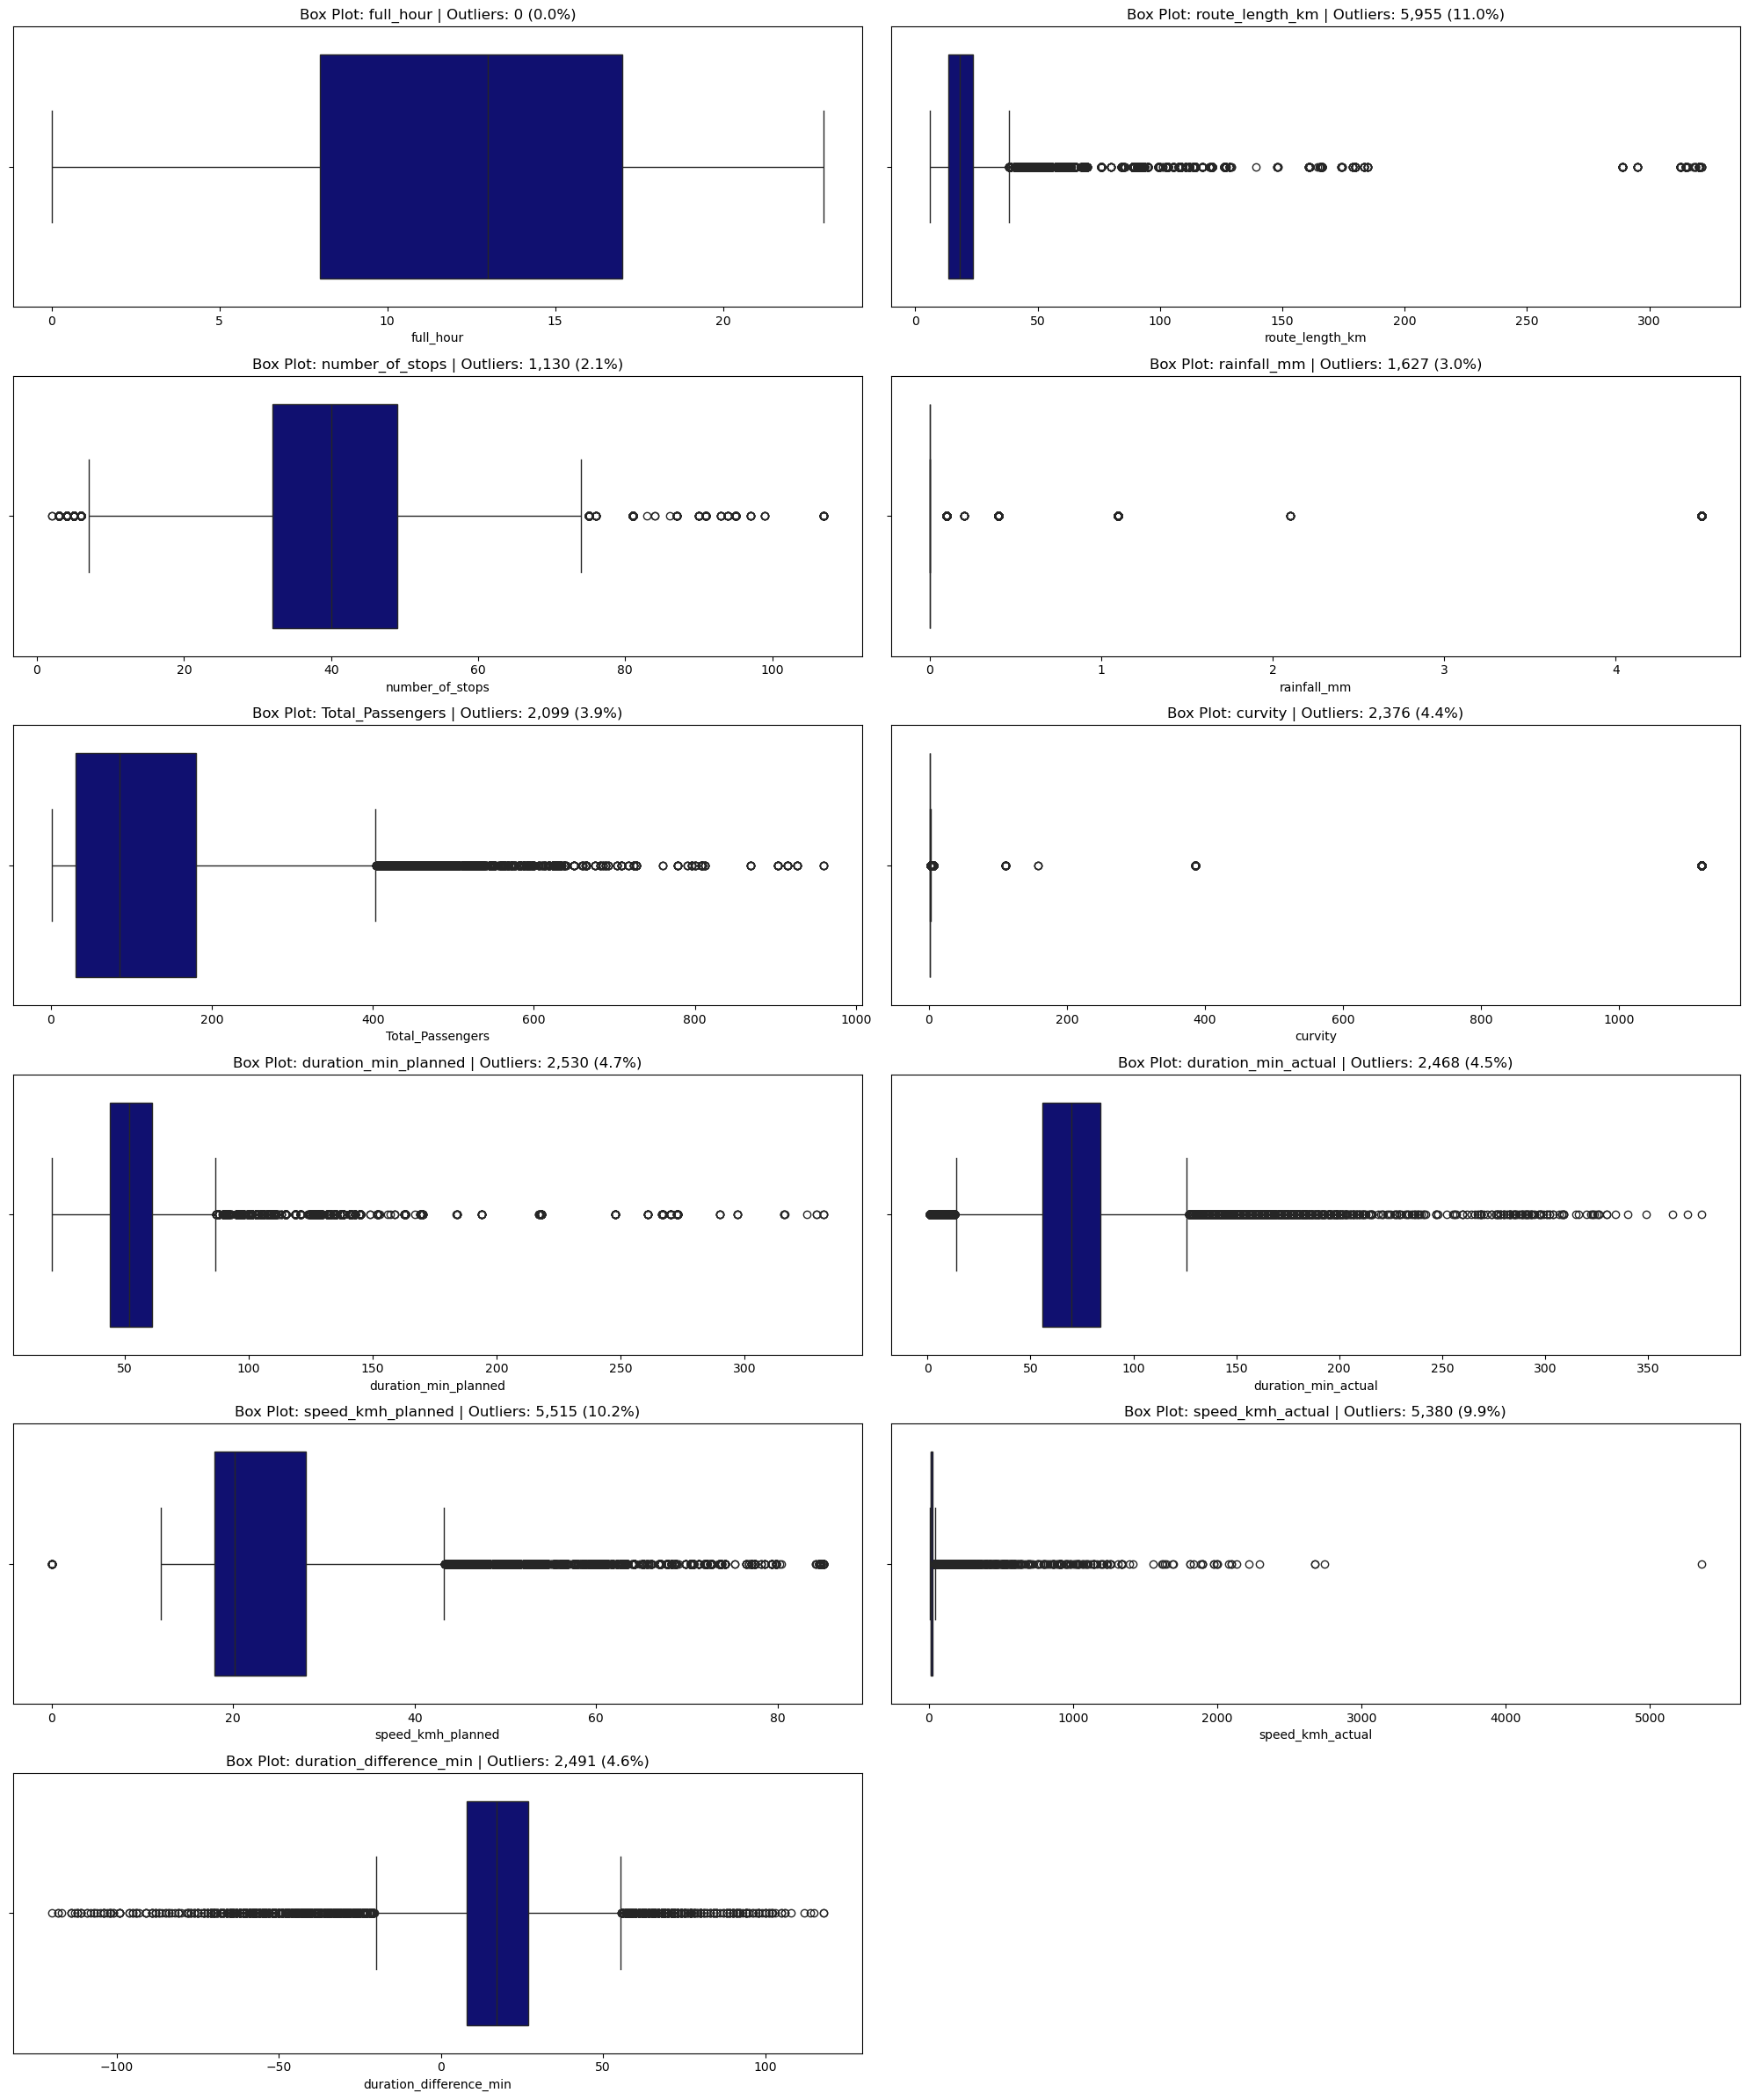

In [215]:
plt.figure(figsize=(20, 24))
cols = ['full_hour', 'route_length_km', 'number_of_stops', 'rainfall_mm', 'Total_Passengers', 
        'curvity', 'duration_min_planned', 'duration_min_actual', 'speed_kmh_planned', 'speed_kmh_actual', 'duration_difference_min']

for i, col in enumerate(cols):
    ax = plt.subplot(6, 2, i + 1)
    sns.boxplot(data=df, x=col, ax=ax, color='navy')
    plt.subplots_adjust(hspace=0.5, wspace=0.3)
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = len(df[(df[col] < lower) | (df[col] > upper)])
    pct_outliers = n_outliers / len(df) * 100
    
    plt.title(f'Box Plot: {col} | Outliers: {n_outliers:,} ({pct_outliers:.1f}%)', fontsize=12)
    plt.xlabel(col, fontsize=10)

plt.tight_layout()
plt.show()

## 5. Categorical Data Handling

In [216]:
def encode_categorical_columns(df, te=None, alternative_cols=None):
    """
    Encode categorical columns.
    """
    # הסר כפילויות לפני הכל
    df = df.loc[:, ~df.columns.duplicated()]
    
    # Ordinal encoding - day
    day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
    day_mapping = {day: i for i, day in enumerate(day_order)}
    df['day_encoded'] = df['day'].map(day_mapping)
    
    # One-Hot encoding - alternative (רק אם לא קיים כבר)
    if 'alternative' in df.columns and 'alternative_#' not in df.columns:
        alternative_dummies = pd.get_dummies(df['alternative'], prefix='alternative')
        
        if alternative_cols is None:
            alternative_cols = alternative_dummies.columns.tolist()
        else:
            for col in alternative_cols:
                if col not in alternative_dummies.columns:
                    alternative_dummies[col] = 0
            alternative_dummies = alternative_dummies[alternative_cols]
        
        df = pd.concat([df, alternative_dummies], axis=1)
    
    # Target encoding
    from category_encoders import TargetEncoder
    target_cols = ['agency_name', 'origin_city', 'destination_city', 
                   'origin_station', 'destination_station']
    
    if te is None:
        te = TargetEncoder()
        df[[f'{col}_encoded' for col in target_cols]] = te.fit_transform(
            df[target_cols], df['duration_difference_min']
        )
    else:
        df[[f'{col}_encoded' for col in target_cols]] = te.transform(
            df[target_cols]
        )

    # Convert alternative bool columns to int
    alt_bool_cols = ['alternative_#', 'alternative_0', 'alternative_1']
    for col in alt_bool_cols:
        if col in df.columns:
            df[col] = df[col].astype(int)    
    
    # הסר כפילויות בסוף
    df = df.loc[:, ~df.columns.duplicated()]
    
    return df, te, alternative_cols

In [217]:
# Run
train_df, te, alternative_cols = encode_categorical_columns(train_df, te=None, alternative_cols=None)
val_df,   _,  _                = encode_categorical_columns(val_df,   te=te,   alternative_cols=alternative_cols)
test_df,  _,  _                = encode_categorical_columns(test_df,  te=te,   alternative_cols=alternative_cols)

# בדוק
print(f"Train:      {train_df.shape[1]} columns")
print(f"Validation: {val_df.shape[1]} columns")
print(f"Test:       {test_df.shape[1]} columns")

Train:      73 columns
Validation: 73 columns
Test:       73 columns


## 6. Feature Selection

In [218]:
def drop_unnecessary_columns(df):
    """Drop columns that are already encoded or not relevant for the model"""
    
    cols_to_drop = [
        # כבר מקודדות
        'day', 'alternative', 'agency_name', 'origin_city',
        'origin_station', 'destination_city', 'destination_station',
        # זהות לעמודות אחרות
        'route_mkt', 'circular_route',
        # טקסט/זמן
        'date', 'line_name', 'departure_time_planned',
        'arrival_time_planned', 'route_type', 'line_num'
    ]
    
    df = df.drop(columns=cols_to_drop, errors='ignore')
    print(f"Columns remaining: {df.shape[1]}")
    
    return df



In [219]:
# Run
train_df = drop_unnecessary_columns(train_df)
val_df   = drop_unnecessary_columns(val_df)
test_df  = drop_unnecessary_columns(test_df)

print(f"\nTrain:      {train_df.shape[1]} columns")
print(f"Validation: {val_df.shape[1]} columns")
print(f"Test:       {test_df.shape[1]} columns")

Columns remaining: 58
Columns remaining: 58
Columns remaining: 58

Train:      58 columns
Validation: 58 columns
Test:       58 columns


In [220]:
from sklearn.feature_selection import VarianceThreshold

# הגדר X ו-y
cols_to_exclude = ['duration_difference_min']
X_train = train_df.drop(columns=cols_to_exclude)
y_train = train_df['duration_difference_min']

# Variance Threshold
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_train)

# עמודות שהוסרו
removed = X_train.columns[~selector.get_support()].tolist()
print(f"Columns removed: {len(removed)}")
print(removed)

# עמודות שנשארו
kept = X_train.columns[selector.get_support()].tolist()
print(f"\nColumns kept: {len(kept)}")

Columns removed: 25
['alternative_2', 'alternative_21', 'alternative_26', 'alternative_3', 'alternative_4', 'alternative_48', 'alternative_49', 'alternative_5', 'alternative_50', 'alternative_6', 'alternative_8', 'alternative_9', 'alternative_א', 'alternative_ב', 'alternative_ד', 'alternative_ז', 'alternative_ח', 'alternative_ט', 'alternative_ך', 'alternative_כ', 'alternative_ם', 'alternative_ן', 'alternative_נ', 'alternative_פ', 'alternative_ק']

Columns kept: 32


In [221]:
# החל על כל הסטים
selected_cols = kept + ['duration_difference_min']

train_df = train_df[selected_cols]
val_df   = val_df[selected_cols]
test_df  = test_df[selected_cols]

print(f"Train:      {train_df.shape[1]} columns")
print(f"Validation: {val_df.shape[1]} columns")
print(f"Test:       {test_df.shape[1]} columns")
print(f"\nFinal features: {kept}")

Train:      33 columns
Validation: 33 columns
Test:       33 columns

Final features: ['full_hour', 'route_id', 'direction', 'number_of_stops', 'route_length_km', 'duration_min_planned', 'duration_min_actual', 'speed_kmh_planned', 'speed_kmh_actual', 'rainfall_mm', 'length_in_buffer_m', 'route_length', 'curvity', 'Total_Passengers', 'Avg_Passengers_Per_Bus', 'is_peak_hour', 'urban', 'perc_within_pt_route', 'perc_within_pt_route_peak', 'passengers_x_peak', 'stops_x_passengers', 'departure_hour', 'arrival_hour', 'day_encoded', 'alternative_#', 'alternative_0', 'alternative_1', 'agency_name_encoded', 'origin_city_encoded', 'destination_city_encoded', 'origin_station_encoded', 'destination_station_encoded']


## 7. Manipulation pipelines

In [224]:
train_df.to_csv(r'../data/model_datasets/train_df_to_ml.csv',index=False,encoding='utf-8-sig')
val_df.to_csv(r'../data/model_datasets/val_df_to_ml.csv',index=False,encoding='utf-8-sig')
test_df.to_csv(r'../data/model_datasets/test_df_to_ml.csv',index=False,encoding='utf-8-sig')
